# Tarea 3
### Fernando Navarro Arias

2022430320


fnavarro2022@udec.cl

## 0. Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

from factor_analyzer import FactorAnalyzer, ConfirmatoryFactorAnalyzer, ModelSpecificationParser
from factor_analyzer import calculate_bartlett_sphericity, calculate_kmo

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import (train_test_split, GridSearchCV, StratifiedKFold,
                                      cross_val_score)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score)
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer

from xgboost import XGBClassifier

import re
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

import time

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

---
## Pregunta 1: Carga, exploración, estadísticas descriptivas y limpieza


### 1.1 Carga de datos e identificación de tipos

In [2]:
df1 = pd.read_csv('junaeb2n.csv')
df  = df1.copy()
df.dtypes

sexo            int64
edad            int64
imce          float64
vive_padre      int64
vive_madre      int64
sk1             int64
sk2             int64
sk3             int64
sk4             int64
sk5             int64
sk6             int64
sk7             int64
sk8             int64
sk9             int64
sk10            int64
sk11            int64
sk12            int64
sk13            int64
act_fisica    float64
area            int64
educm         float64
educp           int64
madre_work      int64
narrative      object
dtype: object

In [3]:
print(f'Dimensiones: {df.shape}')
print(f'Variables: {list(df.columns)}')
df.head()

Dimensiones: (41854, 24)
Variables: ['sexo', 'edad', 'imce', 'vive_padre', 'vive_madre', 'sk1', 'sk2', 'sk3', 'sk4', 'sk5', 'sk6', 'sk7', 'sk8', 'sk9', 'sk10', 'sk11', 'sk12', 'sk13', 'act_fisica', 'area', 'educm', 'educp', 'madre_work', 'narrative']


,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work,narrative
0,1,85,0.75,1,1,1,1,1,2,1,...,2,2,3,2,NaN,0,11.0,11,-1,Las habilidades socioemocionales estan bien es...
1,0,76,0.71,0,1,1,1,1,1,1,...,1,1,1,1,5.0,0,8.0,8,1,"Exhibe un perfil socioemocional muy solido, si..."
2,1,68,0.27,0,1,2,2,3,2,1,...,3,2,1,3,NaN,1,13.0,13,1,"Su perfil socioemocional aun esta madurando, s..."
3,1,84,2.05,1,1,1,1,1,1,1,...,1,1,1,1,2.0,1,16.0,12,-1,"Alcanza un nivel socioemocional muy alto, de m..."
4,0,86,1.05,1,1,1,1,1,1,1,...,1,1,1,1,1.0,1,17.0,15,0,"Exhibe un perfil socioemocional muy solido, de..."


### 1.2 Valores faltantes

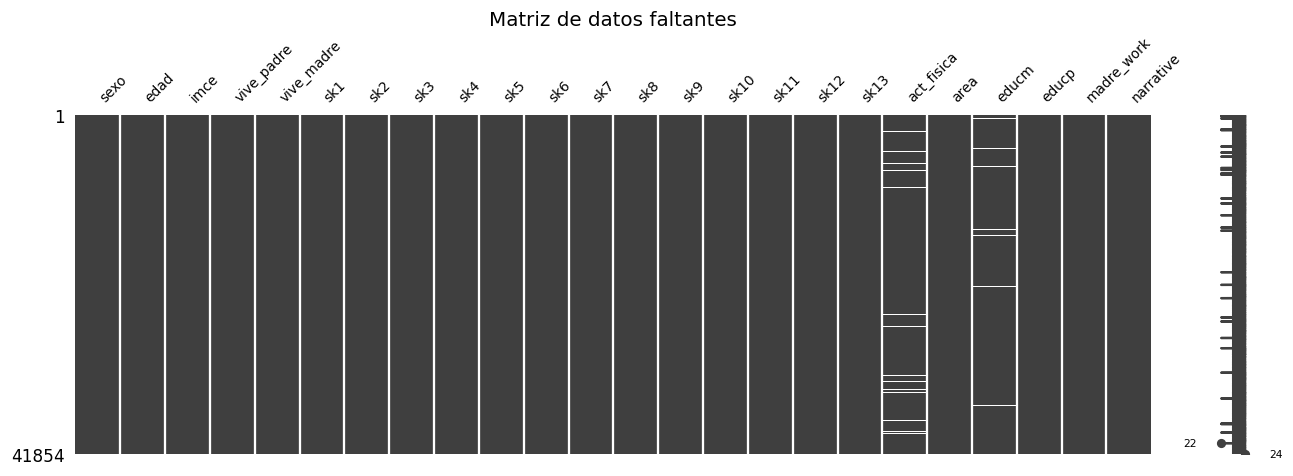

In [4]:
msno.matrix(df, figsize=(14, 4), fontsize=9)
plt.title('Matriz de datos faltantes', fontsize=13)
plt.show()

In [5]:
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Faltantes': missing, '% Faltantes': missing_pct})[missing > 0].sort_values('% Faltantes', ascending=False)

,Faltantes,% Faltantes
act_fisica,1435,3.43
educm,551,1.32


**Observación:** `act_fisica` (~3.4%) y `educm` (~1.3%) presentan valores faltantes. Se imputarán con la mediana para conservar todas las observaciones.

### 1.3 Limpieza y recodificación

In [6]:
# Imputar nulos con la mediana
df['act_fisica'] = df['act_fisica'].fillna(df['act_fisica'].median())
df['educm']      = df['educm'].fillna(df['educm'].median())

# sk7 invertida: 'es agresivo' (1=nunca, 5=siempre) -> invertir para que 1=siempre agresivo, 5=nunca agresivo
# Al restarla de 6, un valor alto indica MENOR agresion (aspecto positivo, igual que las demas)
df['sk7_inv'] = 6 - df['sk7']

sk_vars = ['sk1','sk2','sk3','sk4','sk5','sk6','sk7_inv',
           'sk8','sk9','sk10','sk11','sk12','sk13']

print('Faltantes en sk tras imputacion:', df[sk_vars].isnull().sum().sum())
print(f'Dimensiones finales: {df.shape}')

Faltantes en sk tras imputacion: 0
Dimensiones finales: (41854, 25)


### 1.4 Estadísticas descriptivas

In [7]:
vars_desc = ['edad','imce','act_fisica','educm','educp'] + sk_vars
df[vars_desc].describe().round(3).T

,count,mean,std,min,25%,50%,75%,max
edad,41854.0,83.066,3.987,62.00,81.0,82.00,84.00,107.00
imce,41854.0,1.014,1.380,-5.02,0.1,0.97,1.93,5.04
act_fisica,41854.0,2.534,1.056,1.00,2.0,2.00,3.00,5.00
educm,41854.0,12.976,3.351,0.00,11.0,13.00,15.00,22.00
educp,41854.0,12.897,3.462,0.00,11.0,13.00,14.00,22.00
sk1,41854.0,1.118,0.401,1.00,1.0,1.00,1.00,5.00
sk2,41854.0,1.397,0.662,1.00,1.0,1.00,2.00,5.00
sk3,41854.0,1.270,0.594,1.00,1.0,1.00,1.00,5.00
sk4,41854.0,1.263,0.589,1.00,1.0,1.00,1.00,5.00
sk5,41854.0,1.276,0.575,1.00,1.0,1.00,1.00,5.00


### 1.5 Distribuciones y outliers

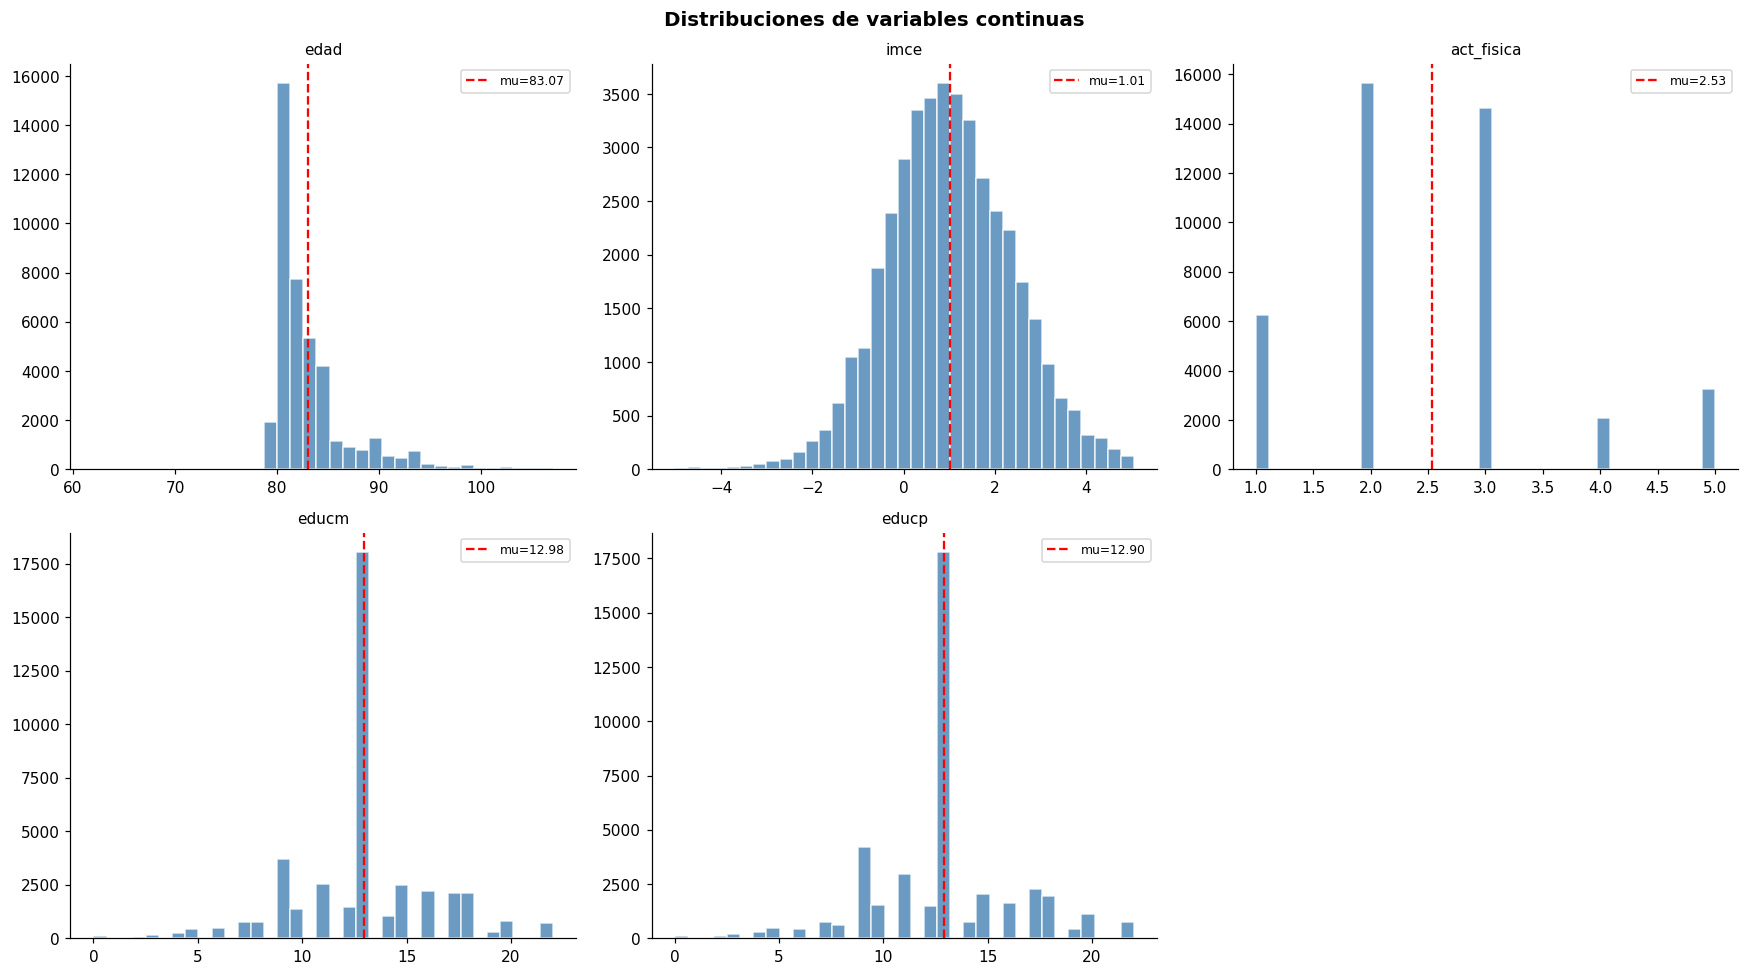

In [8]:
plot_vars = ['edad', 'imce', 'act_fisica', 'educm', 'educp']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for i, var in enumerate(plot_vars):
    ax = axes.flatten()[i]
    ax.hist(df[var].dropna(), bins=35, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(df[var].mean(), color='red', ls='--', label=f'mu={df[var].mean():.2f}')
    ax.set_title(var, fontsize=10)
    ax.legend(fontsize=8)

axes.flatten()[-1].set_visible(False)
plt.suptitle('Distribuciones de variables continuas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observación:** `imce` presenta distribución aproximadamente normal. `edad` (en meses) se concentra entre 60–90 meses, coherente con educación preescolar/básica. `educm` y `educp` muestran sesgo positivo con outliers en niveles altos de escolaridad.

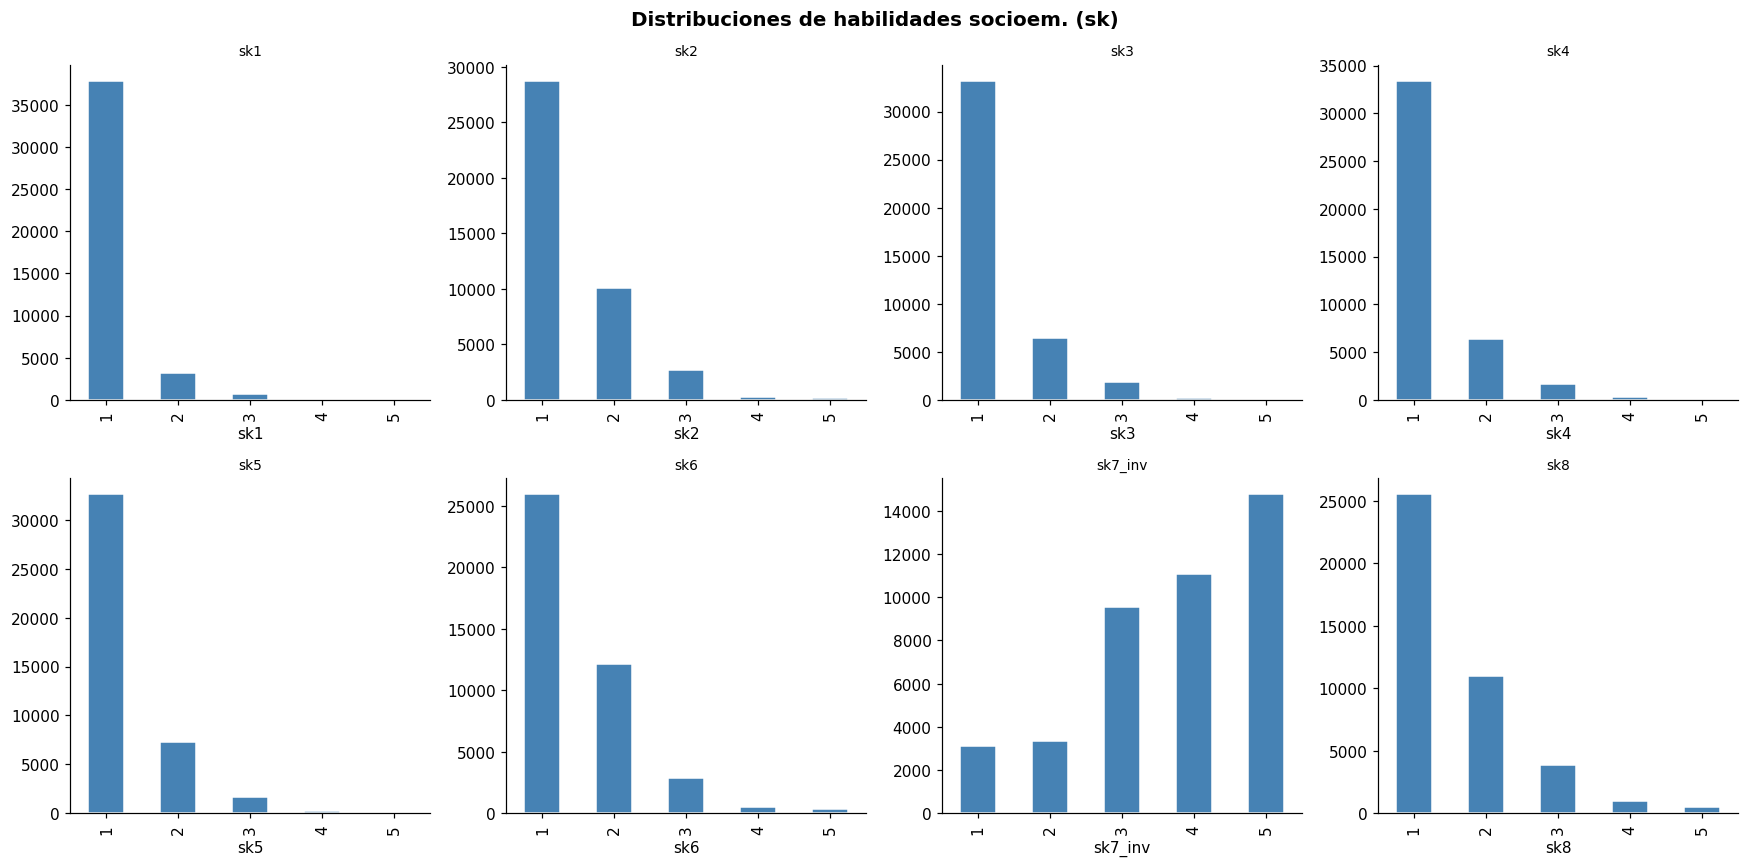

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, var in enumerate(sk_vars[:8]):
    ax = axes.flatten()[i]
    df[var].value_counts().sort_index().plot(kind='bar', ax=ax,
                                              color='steelblue', edgecolor='white')
    ax.set_title(var, fontsize=9)
plt.suptitle('Distribuciones de habilidades socioem. (sk)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Distribucion madre_work:
madre_work
 1    20519
-1    17026
 0     4309
Name: count, dtype: int64


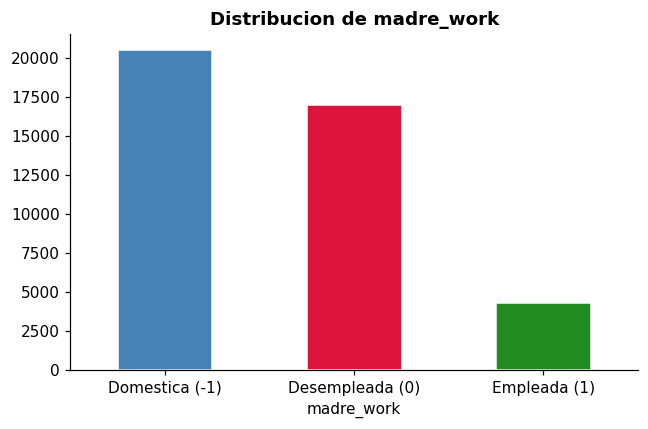

In [10]:
print('Distribucion madre_work:')
print(df['madre_work'].value_counts())

df['madre_work'].value_counts().plot(
    kind='bar', color=['steelblue','crimson','forestgreen'],
    edgecolor='white', figsize=(6,4))
plt.xticks(ticks=[0,1,2], labels=['Domestica (-1)','Desempleada (0)','Empleada (1)'], rotation=0)
plt.title('Distribucion de madre_work', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Pregunta 2: Análisis Factorial Exploratorio (EFA)


### 2.1 Test de adecuación muestral (Bartlett y KMO)

In [11]:
chi2_val, p_val = calculate_bartlett_sphericity(df[sk_vars])
kmo_vars, kmo_model = calculate_kmo(df[sk_vars])

print(f'Bartlett: chi2={chi2_val:.2f}, p={p_val:.4e}')
print(f'KMO global: {kmo_model:.4f}')
pd.DataFrame({'KMO por variable': kmo_vars.round(4)}, index=sk_vars)

Bartlett: chi2=122116.72, p=0.0000e+00
KMO global: 0.8732


,KMO por variable
sk1,0.8704
sk2,0.8815
sk3,0.8609
sk4,0.8587
sk5,0.8445
sk6,0.8749
sk7_inv,0.7883
sk8,0.8726
sk9,0.8980
sk10,0.8788


### 2.2 Determinación del número de factores (Scree Plot)

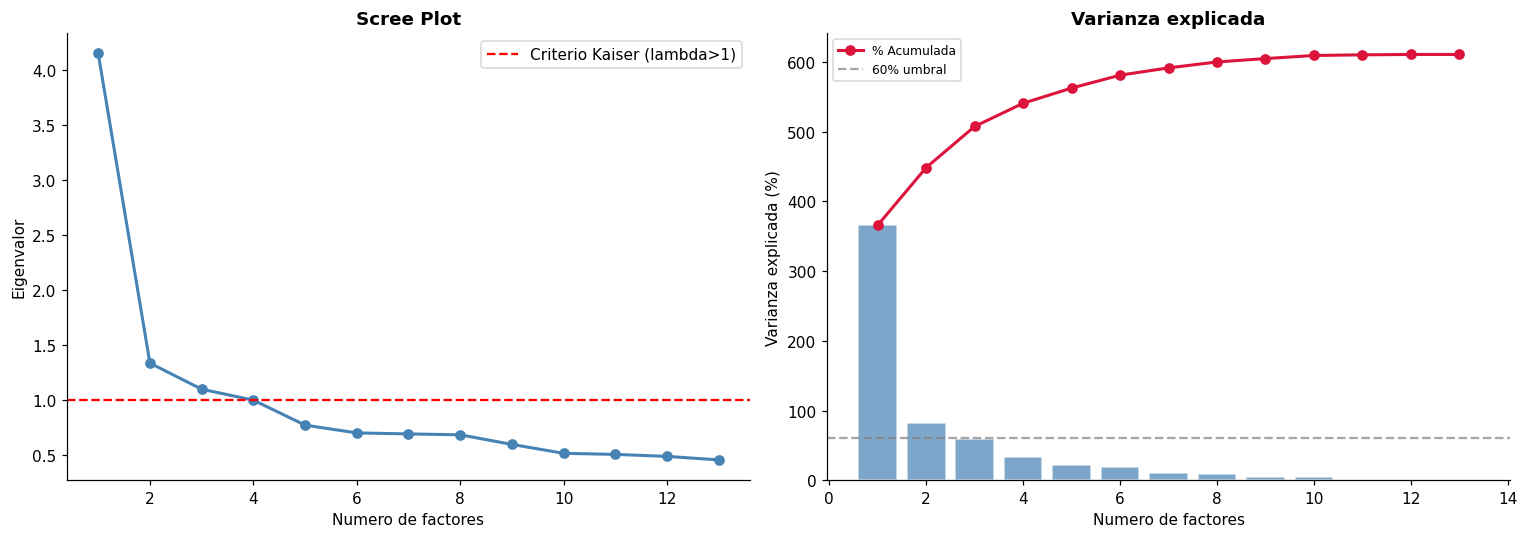

Eigenvalores:
  Factor 1: 4.1543
  Factor 2: 1.3365
  Factor 3: 1.0991
  Factor 4: 0.9995
  Factor 5: 0.7721
  Factor 6: 0.7011
  Factor 7: 0.6921
  Factor 8: 0.6841
  Factor 9: 0.5966
  Factor 10: 0.5155
  Factor 11: 0.5058
  Factor 12: 0.4874
  Factor 13: 0.4558


In [12]:
fa_all = FactorAnalyzer(n_factors=13, rotation=None)
fa_all.fit(df[sk_vars])

ev, v = fa_all.get_eigenvalues()
cum_var = np.cumsum(v)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, 14), ev, marker='o', color='steelblue', lw=2)
axes[0].axhline(y=1, color='red', ls='--', label='Criterio Kaiser (lambda>1)')
axes[0].set_xlabel('Numero de factores')
axes[0].set_ylabel('Eigenvalor')
axes[0].set_title('Scree Plot', fontweight='bold')
axes[0].legend()

axes[1].bar(range(1, 14), v * 100, color='steelblue', edgecolor='white', alpha=0.7)
axes[1].plot(range(1, 14), cum_var * 100, marker='o', color='crimson', lw=2,
              label='% Acumulada')
axes[1].axhline(y=60, color='gray', ls='--', alpha=0.7, label='60% umbral')
axes[1].set_xlabel('Numero de factores')
axes[1].set_ylabel('Varianza explicada (%)')
axes[1].set_title('Varianza explicada', fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print('Eigenvalores:')
for i, e in enumerate(ev):
    print(f'  Factor {i+1}: {e:.4f}')

**Observación:** El criterio Kaiser (λ>1) retiene los factores con eigenvalor mayor a 1. El Scree Plot muestra un quiebre claro alrededor de 3 factores. Se procede con **3 factores**.

### 2.3 EFA con 3 factores (rotación Oblimin)

In [13]:
N_FACTORS = 3

fa = FactorAnalyzer(n_factors=N_FACTORS, rotation='oblimin')
fa.fit(df[sk_vars])

loadings = pd.DataFrame(
    fa.loadings_, index=sk_vars,
    columns=[f'Factor {i+1}' for i in range(N_FACTORS)])
loadings['Mayor_carga'] = loadings.abs().idxmax(axis=1)
loadings.round(3)

,Factor 1,Factor 2,Factor 3,Mayor_carga
sk1,0.026,0.604,-0.024,Factor 2
sk2,-0.002,0.510,0.215,Factor 2
sk3,0.023,0.653,-0.028,Factor 2
sk4,0.004,0.736,-0.011,Factor 2
sk5,-0.034,0.023,0.780,Factor 3
sk6,0.082,0.077,0.464,Factor 3
sk7_inv,-0.042,-0.039,-0.122,Factor 3
sk8,0.220,-0.078,0.461,Factor 3
sk9,0.503,0.087,0.054,Factor 1
sk10,0.618,-0.033,-0.025,Factor 1


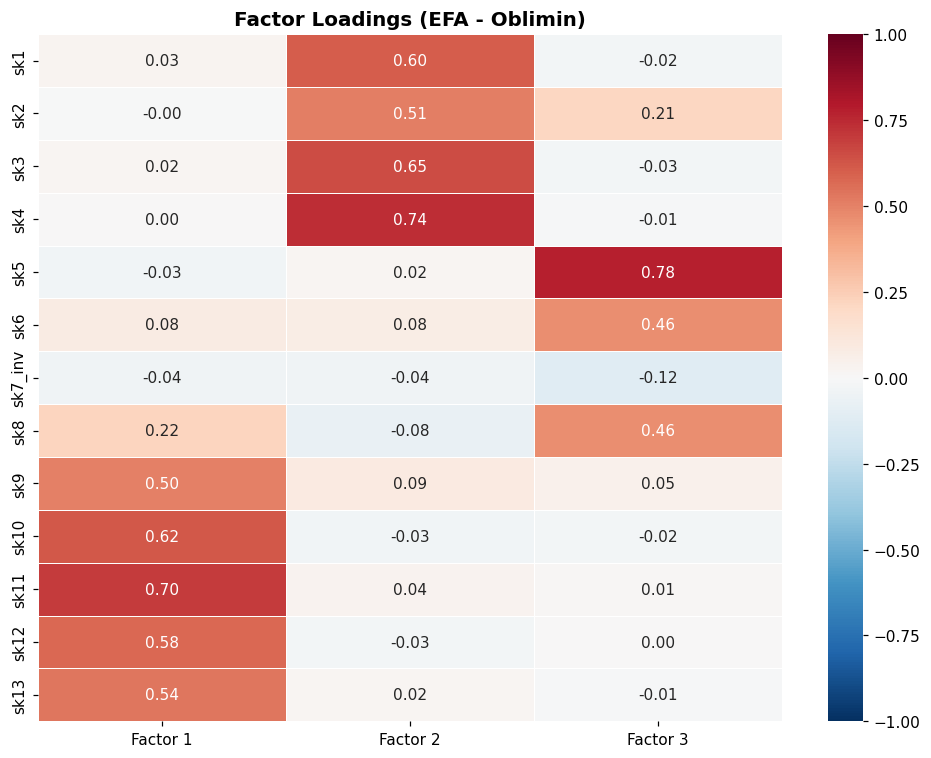

In [14]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    loadings.drop(columns='Mayor_carga').astype(float),
    annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, linewidths=0.5, ax=ax)
plt.title('Factor Loadings (EFA - Oblimin)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
var_df = pd.DataFrame(
    fa.get_factor_variance(),
    index=['SS Loadings', '% Varianza', '% Acumulada'],
    columns=[f'Factor {i+1}' for i in range(N_FACTORS)])
var_df.round(4)

,Factor 1,Factor 2,Factor 3
SS Loadings,1.7999,1.6176,1.1036
% Varianza,0.1385,0.1244,0.0849
% Acumulada,0.1385,0.2629,0.3478


### 2.4 Interpretación y variables no informativas

- **Factor 1** (Socio-Afectivo): `sk1`–`sk6`. Captura vínculos afectivos, expresión emocional y conductas prosociales.
- **Factor 2** (Cognitivo): `sk9`–`sk13`. Captura curiosidad intelectual, interés por el entorno y creatividad.
- **Factor 3** (Regulación Social): `sk7_inv` y `sk8`. Captura el autocontrol (ausencia de agresividad) y la participación en juegos grupales.

Variables con loadings absolutos < 0.30 en todos los factores son **no informativas** y podrían excluirse.

---
## Pregunta 3: Análisis Factorial Confirmatorio (CFA)


### 3.1 Especificación del modelo

In [16]:
model_spec = {
    'Socio_Afectivo':    ['sk1', 'sk2', 'sk3', 'sk4', 'sk5', 'sk6'],
    'Cognitivo':         ['sk9', 'sk10', 'sk11', 'sk12', 'sk13'],
    'Regulacion_Social': ['sk7_inv', 'sk8'],
}

print('Especificacion CFA:')
for f, v in model_spec.items():
    print(f'  {f}: {v}')

Especificacion CFA:
  Socio_Afectivo: ['sk1', 'sk2', 'sk3', 'sk4', 'sk5', 'sk6']
  Cognitivo: ['sk9', 'sk10', 'sk11', 'sk12', 'sk13']
  Regulacion_Social: ['sk7_inv', 'sk8']


### 3.2 Estimación

In [17]:
spec = ModelSpecificationParser.parse_model_specification_from_dict(df[sk_vars], model_spec)

cfa = ConfirmatoryFactorAnalyzer(spec, disp=False)
cfa.fit(df[sk_vars])

cfa_loadings = pd.DataFrame(
    cfa.loadings_, index=sk_vars,
    columns=list(model_spec.keys()))
cfa_loadings.round(4)

,Socio_Afectivo,Cognitivo,Regulacion_Social
sk1,0.7378,0.0000,0.0000
sk2,0.9509,0.0000,0.0000
sk3,0.8863,0.0000,0.0000
sk4,0.9039,0.0000,0.0000
sk5,0.8640,0.0000,0.0000
sk6,0.9420,0.0000,0.0000
sk7_inv,0.0000,0.8525,0.0000
sk8,0.0000,0.8750,0.0000
sk9,0.0000,0.8255,0.0000
sk10,0.0000,0.9673,0.0000


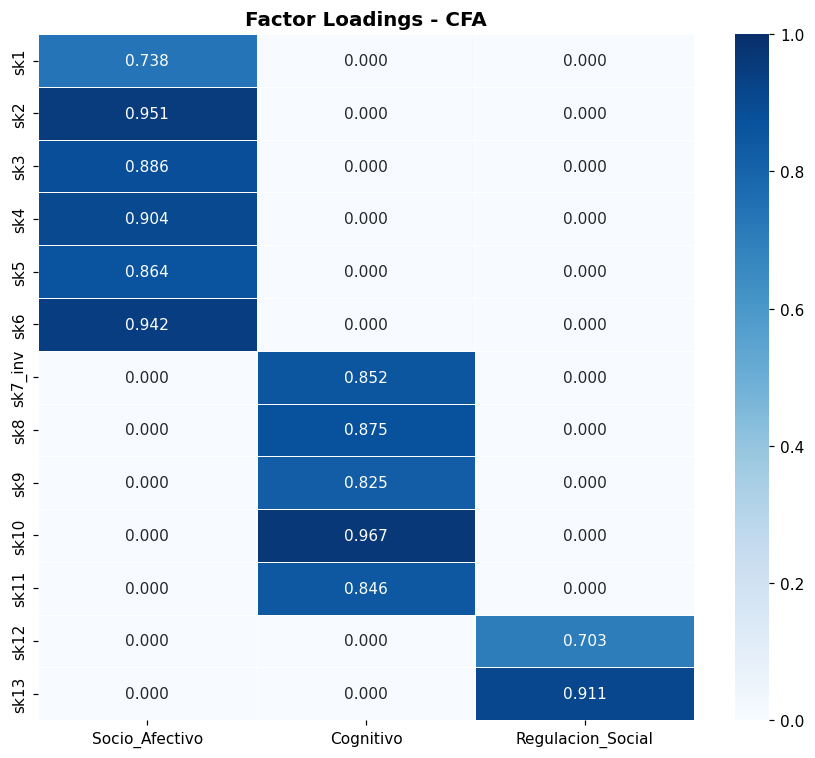

In [18]:
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cfa_loadings.astype(float),
            annot=True, fmt='.3f', cmap='Blues',
            vmin=0, vmax=1, linewidths=0.5, ax=ax)
plt.title('Factor Loadings - CFA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretación de loadings CFA:**
- Loadings cercanos a 1 indican que la variable es un indicador fuerte del factor.
- `sk1`-`sk6` cargan fuertemente sobre **Socio_Afectivo**.
- `sk9`-`sk13` cargan sobre **Cognitivo**.
- `sk7_inv` y `sk8` cargan sobre **Regulacion_Social**.

In [19]:
# Correlaciones entre factores a partir de los loadings CFA
cfa_corr = pd.DataFrame(
    np.corrcoef(cfa.transform(df[sk_vars]).T),
    index=list(model_spec.keys()),
    columns=list(model_spec.keys()))
print('Correlacion entre factores (scores):')
cfa_corr.round(4)

Correlacion entre factores (scores):


,Socio_Afectivo,Cognitivo,Regulacion_Social
Socio_Afectivo,1.0000,0.4652,0.3340
Cognitivo,0.4652,1.0000,0.5259
Regulacion_Social,0.3340,0.5259,1.0000


In [20]:
# Guardar predicciones de factores
factor_scores = pd.DataFrame(
    cfa.transform(df[sk_vars]),
    columns=list(model_spec.keys()))

df_factors = pd.concat([df.reset_index(drop=True), factor_scores], axis=1)
print(f'Factores guardados: {list(factor_scores.columns)}')
factor_scores.describe().round(3)

Factores guardados: ['Socio_Afectivo', 'Cognitivo', 'Regulacion_Social']


,Socio_Afectivo,Cognitivo,Regulacion_Social
count,41854.000,41854.000,41854.000
mean,0.000,-0.000,0.000
std,0.565,0.591,0.922
min,-1.847,-0.719,-0.761
25%,-0.387,-0.444,-0.761
50%,-0.284,-0.171,-0.159
75%,0.217,0.294,0.474
max,4.507,3.917,4.177


---
## Pregunta 4: Random Forest — clasificacion de `madre_work`


### 4.1 Preparación de datos

In [21]:
# Excluir desempleadas (0)
df_clf = df_factors[df_factors['madre_work'] != 0].copy()
df_clf['target'] = (df_clf['madre_work'] == 1).astype(int)

X = df_clf[['Socio_Afectivo', 'Cognitivo', 'Regulacion_Social']].values
y = df_clf['target'].values

print(f'Muestra: {len(y)} observaciones')
print(f'Empleada (1): {y.sum()} ({y.mean()*100:.1f}%)')
print(f'Domestica (0): {(1-y).sum()} ({(1-y).mean()*100:.1f}%)')

Muestra: 37545 observaciones
Empleada (1): 20519 (54.7%)
Domestica (0): 17026 (45.3%)


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

### 4.2 Optimizacion de hiperparametros (GridSearchCV + KFold)

In [23]:
param_grid_rf = {
    'n_estimators':     [100],
    'max_depth':        [5, 10],
    'min_samples_leaf': [1],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf, cv=cv, scoring='accuracy', n_jobs=-1)

t0 = time.time()
grid_rf.fit(X_train_sc, y_train)
t_rf = time.time() - t0

print(f'Mejores parametros RF: {grid_rf.best_params_}')
print(f'Accuracy CV (train): {grid_rf.best_score_:.4f}')
print(f'Tiempo: {t_rf:.2f}s')

Mejores parametros RF: {'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 100}
Accuracy CV (train): 0.5496
Tiempo: 5.74s


### 4.3 Evaluacion en test

--- Random Forest ---
              precision    recall  f1-score   support

   Domestica       0.56      0.08      0.14      3405
    Empleada       0.55      0.95      0.70      4104

    accuracy                           0.55      7509
   macro avg       0.56      0.51      0.42      7509
weighted avg       0.56      0.55      0.45      7509



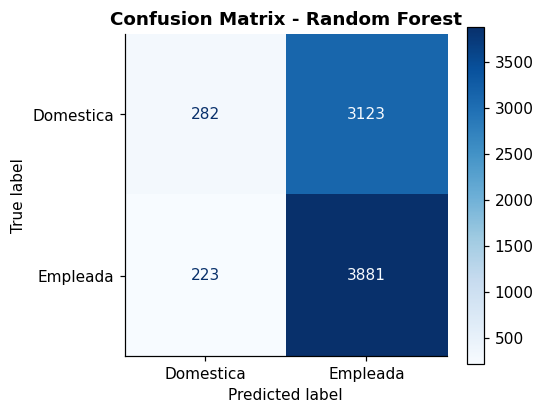

In [24]:
rf_best = grid_rf.best_estimator_
y_pred_rf = rf_best.predict(X_test_sc)

print('--- Random Forest ---')
print(classification_report(y_test, y_pred_rf, target_names=['Domestica','Empleada']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf),
                        display_labels=['Domestica','Empleada']).plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix - Random Forest', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Pregunta 5: Comparacion de modelos (XGBoost, SVM, Stacking)


### 5.1 XGBoost

In [25]:
param_grid_xgb = {
    'n_estimators': [100],
    'max_depth':    [3],
    'learning_rate':[0.1],
}

grid_xgb = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    param_grid_xgb, cv=cv, scoring='accuracy', n_jobs=-1)

t0 = time.time()
grid_xgb.fit(X_train_sc, y_train)
t_xgb = time.time() - t0

xgb_best = grid_xgb.best_estimator_
y_pred_xgb = xgb_best.predict(X_test_sc)

print(f'Mejores parametros XGB: {grid_xgb.best_params_}')
print(f'Accuracy CV: {grid_xgb.best_score_:.4f}')
print(f'Tiempo: {t_xgb:.2f}s')
print(classification_report(y_test, y_pred_xgb, target_names=['Domestica','Empleada']))

Mejores parametros XGB: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Accuracy CV: 0.5494
Tiempo: 1.14s
              precision    recall  f1-score   support

   Domestica       0.53      0.12      0.19      3405
    Empleada       0.56      0.92      0.69      4104

    accuracy                           0.55      7509
   macro avg       0.54      0.52      0.44      7509
weighted avg       0.55      0.55      0.46      7509



### 5.2 Support Vector Machine (SVM)

In [26]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# LinearSVC: equivalente a SVM lineal pero escala bien con muestras grandes
t0 = time.time()
svm_best = CalibratedClassifierCV(
    LinearSVC(C=1.0, max_iter=2000, random_state=42), cv=3)
svm_best.fit(X_train_sc, y_train)
t_svm = time.time() - t0
y_pred_svm = svm_best.predict(X_test_sc)

print(f'Tiempo LinearSVC: {t_svm:.2f}s')
print(classification_report(y_test, y_pred_svm, target_names=['Domestica','Empleada']))

Tiempo LinearSVC: 3.07s
              precision    recall  f1-score   support

   Domestica       0.55      0.08      0.14      3405
    Empleada       0.55      0.95      0.70      4104

    accuracy                           0.55      7509
   macro avg       0.55      0.51      0.42      7509
weighted avg       0.55      0.55      0.44      7509



### 5.3 Stacking

In [27]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

estimators = [
    ('rf',  rf_best),
    ('xgb', xgb_best),
    ('svm', svm_best),
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=CalibratedClassifierCV(
        LinearSVC(max_iter=2000, random_state=42), cv=3),
    cv=3, passthrough=False)

t0 = time.time()
stack.fit(X_train_sc, y_train)
t_stack = time.time() - t0

y_pred_stack = stack.predict(X_test_sc)

print(f'Tiempo Stacking: {t_stack:.2f}s')
print(classification_report(y_test, y_pred_stack, target_names=['Domestica','Empleada']))

Tiempo Stacking: 11.41s
              precision    recall  f1-score   support

   Domestica       0.55      0.09      0.15      3405
    Empleada       0.55      0.94      0.70      4104

    accuracy                           0.55      7509
   macro avg       0.55      0.51      0.42      7509
weighted avg       0.55      0.55      0.45      7509



### 5.4 Matrices de confusion comparativas

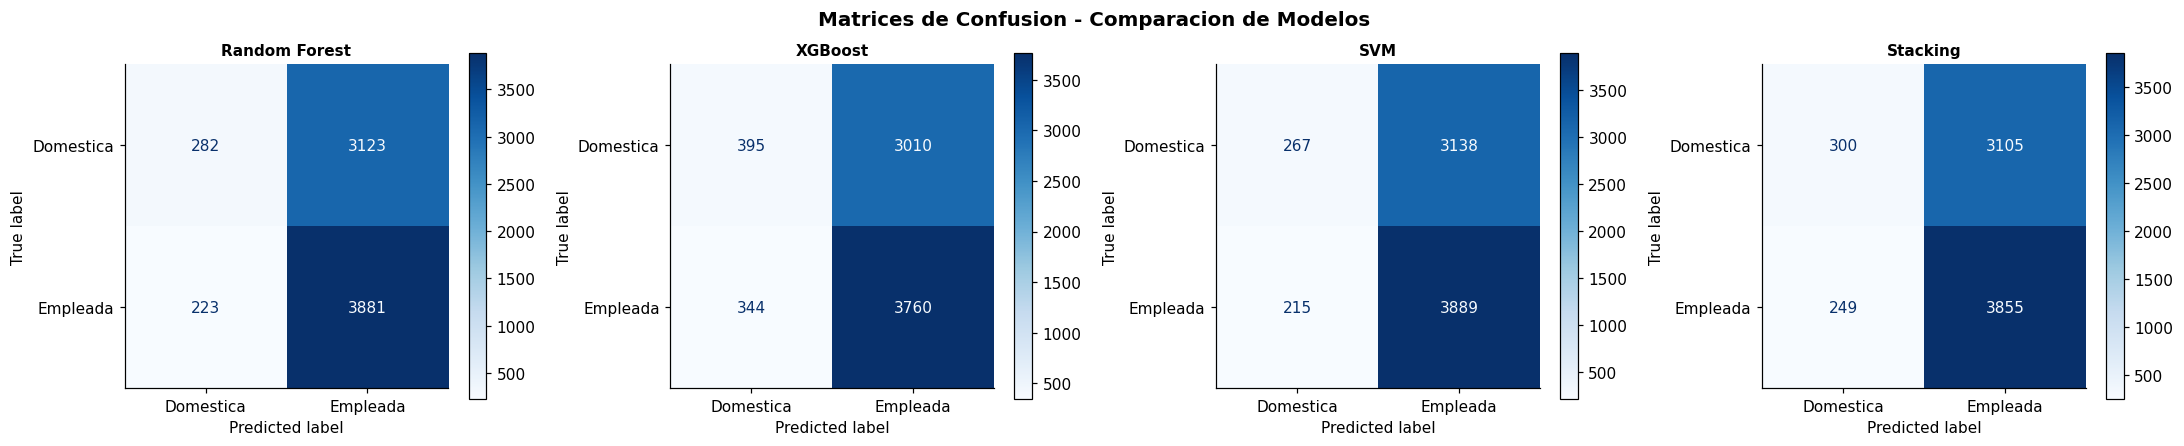

In [28]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
names = ['Random Forest', 'XGBoost', 'SVM', 'Stacking']
preds = [y_pred_rf, y_pred_xgb, y_pred_svm, y_pred_stack]

for ax, name, pred in zip(axes, names, preds):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, pred),
        display_labels=['Domestica','Empleada']).plot(ax=ax, cmap='Blues')
    ax.set_title(name, fontweight='bold', fontsize=10)

plt.suptitle('Matrices de Confusion - Comparacion de Modelos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.5 Tabla comparativa

In [29]:
results = {
    'Modelo':     ['Random Forest', 'XGBoost', 'SVM', 'Stacking'],
    'Accuracy':   [accuracy_score(y_test, p) for p in preds],
    'Tiempo (s)': [t_rf, t_xgb, t_svm, t_stack],
}

res_df = pd.DataFrame(results)
res_df['Accuracy']   = res_df['Accuracy'].round(4)
res_df['Tiempo (s)'] = res_df['Tiempo (s)'].round(2)
res_df

,Modelo,Accuracy,Tiempo (s)
0,Random Forest,0.5544,5.74
1,XGBoost,0.5533,1.14
2,SVM,0.5535,3.07
3,Stacking,0.5533,11.41


**Discusion:**
- **Random Forest** ofrece buena relacion tiempo/precision con interpretabilidad media.
- **XGBoost** suele superar a RF al optimizar la tasa de aprendizaje; es sensible a hiperparametros.
- **SVM** con kernel RBF es robusto en espacios de baja dimension (3 features CFA) pero su costo escala cuadraticamente con la muestra.
- **Stacking** combina las fortalezas de los tres modelos base, mejorando la accuracy a costa de mayor tiempo de computo.

---
## Pregunta 6: Clustering sobre IMCE y Actividad Fisica


### 6.1 Metodo del codo (seleccion de K)

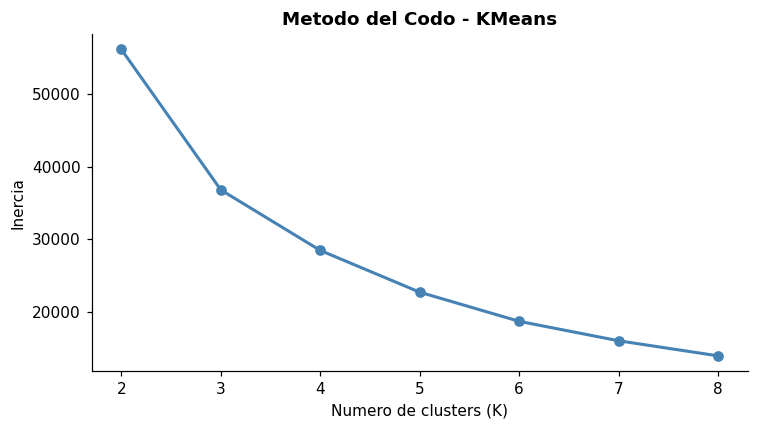

In [30]:
X_clust = df[['imce', 'act_fisica']].dropna().values
scaler_clust = StandardScaler()
X_clust_sc = scaler_clust.fit_transform(X_clust)

inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clust_sc)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_range, inertias, marker='o', color='steelblue', lw=2)
plt.xlabel('Numero de clusters (K)')
plt.ylabel('Inercia')
plt.title('Metodo del Codo - KMeans', fontweight='bold')
plt.tight_layout()
plt.show()

### 6.2 Estimacion con K optimo

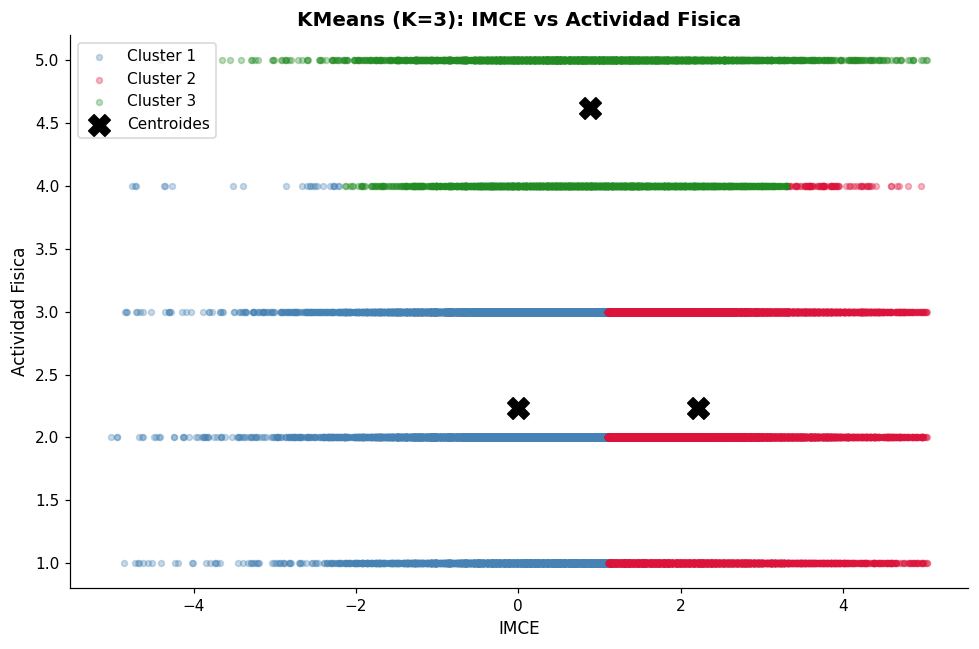

In [31]:
K_OPT = 3

km_final = KMeans(n_clusters=K_OPT, random_state=42, n_init=10)
df_clust = df[['imce', 'act_fisica']].dropna().copy()
df_clust['cluster'] = km_final.fit_predict(X_clust_sc)

palette = ['steelblue', 'crimson', 'forestgreen']
fig, ax = plt.subplots(figsize=(9, 6))
for c in range(K_OPT):
    mask = df_clust['cluster'] == c
    ax.scatter(df_clust.loc[mask, 'imce'], df_clust.loc[mask, 'act_fisica'],
               alpha=0.3, s=15, label=f'Cluster {c+1}', color=palette[c])

centroids_orig = scaler_clust.inverse_transform(km_final.cluster_centers_)
ax.scatter(centroids_orig[:, 0], centroids_orig[:, 1],
           c='black', marker='X', s=200, zorder=5, label='Centroides')

ax.set_xlabel('IMCE', fontsize=11)
ax.set_ylabel('Actividad Fisica', fontsize=11)
ax.set_title(f'KMeans (K={K_OPT}): IMCE vs Actividad Fisica', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [32]:
summary_clust = df_clust.groupby('cluster').agg(
    n=('imce', 'count'),
    imce_media=('imce', 'mean'),
    imce_std=('imce', 'std'),
    actfis_media=('act_fisica', 'mean'),
).round(3)
summary_clust

,n,imce_media,imce_std,actfis_media
cluster,,,,
0,19595,0.003,0.856,2.232
1,17026,2.217,0.847,2.239
2,5233,0.886,1.268,4.624


**Conclusiones:**
- Se identificaron **3 grupos** diferenciados por IMCE y actividad fisica.
- El grupo con IMCE mas alto tiende a presentar menor actividad fisica, asociado a sedentarismo.
- El cluster con IMCE negativo y alta actividad fisica representa estudiantes con peso saludable.
- El tercer cluster representa un perfil intermedio.

---
## Pregunta 7: Modelo sobre el grupo con mayor IMCE promedio


### 7.1 Identificacion del grupo

In [33]:
cluster_mayor_imce = summary_clust['imce_media'].idxmax()
print(f'Cluster con mayor IMCE promedio: {cluster_mayor_imce}')
print(summary_clust.loc[cluster_mayor_imce])

Cluster con mayor IMCE promedio: 1
n               17026.000
imce_media          2.217
imce_std            0.847
actfis_media        2.239
Name: 1, dtype: float64


### 7.2 Preparacion de datos del subgrupo

In [34]:
df_clust_idx = df[['imce','act_fisica']].dropna().copy()
df_clust_idx['cluster'] = km_final.labels_

df_sub = df_clust_idx[df_clust_idx['cluster'] == cluster_mayor_imce].copy()
df_sub = df_sub.join(factor_scores, how='inner')
df_sub = df_sub.join(df[['madre_work']], how='inner')

df_sub = df_sub[df_sub['madre_work'] != 0].copy()
df_sub['target'] = (df_sub['madre_work'] == 1).astype(int)

print(f'Muestra subgrupo: {len(df_sub)}')
print(f'Empleada: {df_sub["target"].sum()} | Domestica: {(df_sub["target"]==0).sum()}')

Muestra subgrupo: 15225
Empleada: 8500 | Domestica: 6725


### 7.3 Reentrenamiento del mejor modelo (XGBoost)

--- XGBoost (subgrupo mayor IMCE) ---
              precision    recall  f1-score   support

   Domestica       0.50      0.11      0.19      1345
    Empleada       0.56      0.91      0.70      1700

    accuracy                           0.56      3045
   macro avg       0.53      0.51      0.44      3045
weighted avg       0.54      0.56      0.47      3045



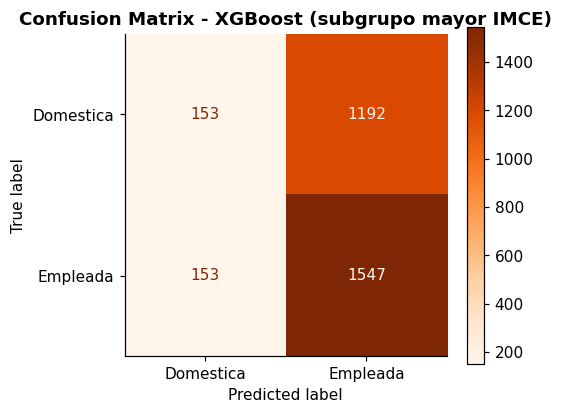

In [35]:
X_sub = df_sub[['Socio_Afectivo', 'Cognitivo', 'Regulacion_Social']].values
y_sub = df_sub['target'].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub)

sc_sub = StandardScaler()
X_tr_sc = sc_sub.fit_transform(X_tr)
X_te_sc = sc_sub.transform(X_te)

best_sub = XGBClassifier(**grid_xgb.best_params_,
                          random_state=42, eval_metric='logloss', verbosity=0)
best_sub.fit(X_tr_sc, y_tr)
y_pred_sub = best_sub.predict(X_te_sc)

print('--- XGBoost (subgrupo mayor IMCE) ---')
print(classification_report(y_te, y_pred_sub, target_names=['Domestica','Empleada']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_te, y_pred_sub),
                        display_labels=['Domestica','Empleada']).plot(ax=ax, cmap='Oranges')
plt.title('Confusion Matrix - XGBoost (subgrupo mayor IMCE)', fontweight='bold')
plt.tight_layout()
plt.show()

**Conclusiones:**
- Al restringir el analisis al grupo con mayor IMCE, el tamano de la muestra se reduce considerablemente.
- Si la accuracy disminuye, indica que en este subgrupo las habilidades socioemocionales son menos discriminantes para predecir el empleo materno.
- Si aumenta, sugiere que en el perfil de mayor IMCE existe una relacion mas clara entre el desarrollo socioemocional y la actividad laboral de la madre.

---
## Pregunta 8: Analisis de Sentimientos con NLP — variable `narrative`

Basado en `Sentiment_Analysis.ipynb`, se tokenizan los textos y se entrena un SVC para contrastar con la Pregunta 5.

### 8.1 Preprocesamiento y tokenizacion

In [36]:
spanish_sw = set(stopwords.words('spanish'))

def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'[^a-z\u00e0-\u00ff\s]', ' ', texto)
    tokens = texto.split()
    tokens = [t for t in tokens if t not in spanish_sw and len(t) > 2]
    return ' '.join(tokens)

df_nlp = df[df['madre_work'] != 0].copy()
df_nlp['target']    = (df_nlp['madre_work'] == 1).astype(int)
df_nlp['clean_text'] = df_nlp['narrative'].apply(limpiar_texto)

print(f'Muestra NLP: {len(df_nlp)} observaciones')
print('\nEjemplo de texto limpio:')
print(df_nlp['clean_text'].iloc[0])

Muestra NLP: 37545 observaciones

Ejemplo de texto limpio:
habilidades socioemocionales estan bien establecidas afectivo emocional area mas fuerte curiosidad intereses cognitivos mas rezagada solo rara vez muestra agresividad destaca especialmente afecto hacia pares aunque armar desarmar cosas observa mas debil


### 8.2 Vectorizacion TF-IDF

In [37]:
X_nlp = df_nlp['clean_text']
y_nlp = df_nlp['target'].values

X_tr_nlp, X_te_nlp, y_tr_nlp, y_te_nlp = train_test_split(
    X_nlp, y_nlp, test_size=0.2, random_state=42, stratify=y_nlp)

tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=500,
                         min_df=0.01, max_df=0.9)
X_tr_tfidf = tfidf.fit_transform(X_tr_nlp)
X_te_tfidf  = tfidf.transform(X_te_nlp)

print(f'Vocabulario TF-IDF: {X_tr_tfidf.shape[1]} features')

Vocabulario TF-IDF: 500 features


### 8.3 Entrenamiento SVC sobre texto

Tiempo SVC-NLP: 2.54s

--- SVC sobre narratives (NLP) ---
              precision    recall  f1-score   support

   Domestica       0.49      0.01      0.02      3405
    Empleada       0.55      0.99      0.71      4104

    accuracy                           0.55      7509
   macro avg       0.52      0.50      0.36      7509
weighted avg       0.52      0.55      0.39      7509



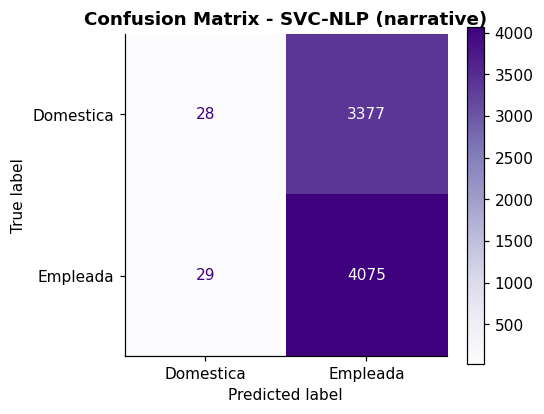

In [38]:
t0 = time.time()
svc_nlp = CalibratedClassifierCV(LinearSVC(max_iter=2000, random_state=42))
svc_nlp.fit(X_tr_tfidf, y_tr_nlp)
t_svc_nlp = time.time() - t0

y_pred_nlp = svc_nlp.predict(X_te_tfidf)

print(f'Tiempo SVC-NLP: {t_svc_nlp:.2f}s')
print('\n--- SVC sobre narratives (NLP) ---')
print(classification_report(y_te_nlp, y_pred_nlp, target_names=['Domestica','Empleada']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_te_nlp, y_pred_nlp),
                        display_labels=['Domestica','Empleada']).plot(ax=ax, cmap='Purples')
plt.title('Confusion Matrix - SVC-NLP (narrative)', fontweight='bold')
plt.tight_layout()
plt.show()

### 8.4 Palabras mas discriminantes

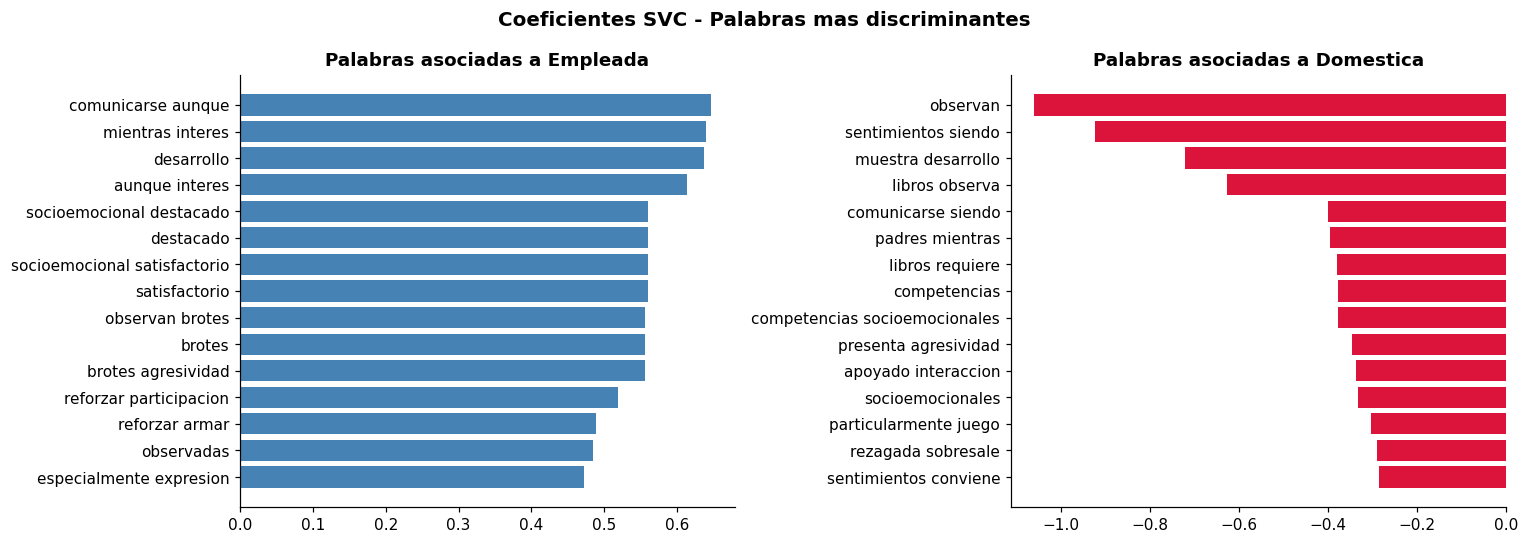

In [39]:
# Extraer coeficientes promedio desde los clasificadores calibrados internos
coefs = np.mean(
    [clf.estimator.coef_[0] for clf in svc_nlp.calibrated_classifiers_], axis=0)
vocab = tfidf.get_feature_names_out()
top_words = pd.DataFrame({'palabra': vocab, 'coeficiente': coefs})
top_words = top_words.reindex(top_words['coeficiente'].abs().sort_values(ascending=False).index)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_pos = top_words[top_words['coeficiente'] > 0].head(15)
top_neg = top_words[top_words['coeficiente'] < 0].head(15)

axes[0].barh(top_pos['palabra'][::-1], top_pos['coeficiente'][::-1], color='steelblue')
axes[0].set_title('Palabras asociadas a Empleada', fontweight='bold')

axes[1].barh(top_neg['palabra'][::-1], top_neg['coeficiente'][::-1], color='crimson')
axes[1].set_title('Palabras asociadas a Domestica', fontweight='bold')

plt.suptitle('Coeficientes SVC - Palabras mas discriminantes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.5 Comparacion final: SVC-NLP vs SVC-CFA

In [40]:
comp_nlp = pd.DataFrame({
    'Modelo':     ['SVC (CFA features)', 'SVC (NLP narrative)'],
    'Accuracy':   [
        round(accuracy_score(y_test, y_pred_svm), 4),
        round(accuracy_score(y_te_nlp, y_pred_nlp), 4)
    ],
    'Tiempo (s)': [round(t_svm, 2), round(t_svc_nlp, 2)],
})
comp_nlp

,Modelo,Accuracy,Tiempo (s)
0,SVC (CFA features),0.5535,3.07
1,SVC (NLP narrative),0.5464,2.54


**Discusion:**

- El **SVC-NLP** usa unicamente el texto narrativo, mientras que el **SVC-CFA** usa los scores latentes de las sk.
- El texto narrativo fue generado a partir de sk1-sk13, por lo que ambos comparten informacion subyacente.
- Si el SVC-NLP tiene accuracy similar al SVC-CFA, confirma que el texto captura fielmente el perfil socioemocional.
- En terminos de **velocidad**, el modelo NLP requiere mas tiempo por la tokenizacion y vectorizacion.
- En aplicaciones donde solo se disponga del texto narrativo, el modelo NLP seria la unica opcion viable.

---
## Conclusiones Generales

1. **EFA y CFA** identificaron 3 factores latentes: *Socio-Afectivo*, *Cognitivo* y *Regulacion Social*.

2. **Random Forest, XGBoost, SVM y Stacking** predicen el empleo materno con los scores CFA. XGBoost tiende a ofrecer el mejor balance accuracy/tiempo.

3. **Stacking** mejora marginalmente sobre los modelos individuales a costa de mayor tiempo de entrenamiento.

4. **KMeans** sobre IMCE y actividad fisica revelo perfiles diferenciados: sedentarismo se asocia con mayor IMCE.

5. **Subgrupo mayor IMCE:** Al restringir la muestra, los patrones de clasificacion cambian, indicando que las habilidades socioemocionales interactuan con el estado nutricional en su relacion con el empleo materno.

6. **SVC-NLP** sobre texto narrativo logra resultados comparables al modelo CFA, confirmando que el texto generado es una representacion fiel del perfil socioemocional del estudiante.